In [3]:
!pip install yellowbrick

In [4]:
!pip install factor_analyzer

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor_analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=3ae7264f296d2c18100c57410390665e79d15b32a9ba8ff60e7e6f0ec73602ba
  Stored in directory: /Users/ananaska/Library/Caches/pip/wheels/87/6e/8f/914f20e0242ee0214e5c8336031a2fab12e632e4695fbb7276
Successfully built factor_analyzer


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
from itertools import product
from scipy.stats.mstats import zscore
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.cluster import KMeans, DBSCAN
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.metrics import calinski_harabasz_score, silhouette_score
from yellowbrick.cluster import KElbowVisualizer
from factor_analyzer import FactorAnalyzer, Rotator, calculate_bartlett_sphericity, calculate_kmo
import warnings
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv('school_vacancies_clean.csv')
df

,id,stateRegionCode,vacancyName,codeProfession,codeProfessionalSphere,professionalSphereName,vacancyAddress,vacancyAddressHouse,geo,salary,...,JobRole_Режим гибкого рабочего времени,JobRole_Сменная работа,JobRole_Временная,JobRole_Полная занятость,JobRole_Сезонная,JobRole_Стажировка,JobRole_Удалённая,JobRole_Частичная занятость,school_suitability_index,federal_district
0,eeaddde8-f5d0-11f0-ba7d-9959eb3311ba,3100000000000,Уборщик производственных и служебных помещений,192624.0,Education,"Образование, наука","Белгородская область, Город Губкин, Мичурина у...",дом: ЗД. 21;,"{""latitude"": 51.28298, ""longitude"": 37.529349}",27100,...,0,0,1,0,0,0,0,0,1,Центральный
1,74fb9f78-f533-11f0-a027-0dd543315e5a,5200000000000,Помощник,177874.0,Industry,Производство,"Нижегородская область, Город Нижний Новгород, ...",дом: Д.5;,"{""latitude"": 56.250627, ""longitude"": 43.976396}",28000,...,0,0,0,1,0,0,0,0,0,Приволжский
2,0bb2daf0-e166-11f0-a6fd-690b9f9d74c0,5200000000000,Гардеробщик,116334.0,Culture,"Искусство, культура и развлечения","Нижегородская область, Город Дзержинск, Ленина...",дом: 62;,"{""latitude"": 56.237197, ""longitude"": 43.456541}",27093,...,0,0,0,1,0,0,0,0,0,Приволжский
3,4297f4e9-f68a-11f0-a027-0dd543315e5a,5200000000000,Уборщик производственных и служебных помещений,192588.0,Education,"Образование, наука","Нижегородская область, Город Выкса, Братьев Ба...",дом: ЗД. 3;,"{""latitude"": 55.320565, ""longitude"": 42.151576}",27903,...,0,0,0,1,0,0,0,0,0,Приволжский
4,07e57c50-f6bc-11f0-8628-a3cca5294b78,6800000000000,Подсобный рабочий,167711.0,Industry,Производство,"Тамбовская область, Мордовский район, Промышле...",строение 1,"{""latitude"": 52.133137, ""longitude"": 40.824028}",28571,...,0,0,1,0,0,0,0,0,1,Центральный
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2208,e02fe0b4-f76f-11f0-ba7d-9959eb3311ba,5200000000000,Подсобный рабочий,167711.0,Communal,"ЖКХ, эксплуатация","Нижегородская область, Город Выкса, Досчатое р...",дом ЗДАН 1,"{""latitude"": 55.378473, ""longitude"": 42.127672}",27093,...,0,0,0,0,0,0,0,1,1,Приволжский
2209,de298c18-0004-11f1-b4ed-438ed61bfb06,3800000000000,Подсобный рабочий,167711.0,ChemicalAndFuelIndustry,"Химическая, нефтехимическая, топливная промышл...","Иркутская область, Город Ангарск, Первый промы...",строение 5,"{""latitude"": 52.562356, ""longitude"": 103.88754}",30642,...,0,0,1,0,0,0,0,0,1,Сибирский
2210,fe989fbc-f2ab-11f0-8628-a3cca5294b78,3800000000000,Подсобный рабочий,167711.0,NotQualification,"Работы, не требующие квалификации","Иркутская область, Город Иркутск, Розы Люксемб...",дом: Д. 184;,"{""latitude"": 52.356439, ""longitude"": 104.15991}",8805,...,0,0,0,1,0,0,0,0,0,Сибирский
2211,fe2217b8-f2cd-11f0-8628-a3cca5294b78,100000000000,Помощник,132479.0,DeskWork,"Административная работа, секретариат, АХО","Республика Адыгея (Адыгея), Тахтамукайский рай...",9/2 офис 1,"{""latitude"": 44.930838, ""longitude"": 38.927675}",27093,...,0,0,0,1,0,0,0,0,0,Южный


**1. Построение признакового пространства и снижение размерности для кластеризации**

Отобранные признаки:
- salary_cluster, зарплата, после винзоризации устранены выбросы.
- exp_scaled, требования к опыту. Масштабирован, отражает доступность вакансии для школьников.
- workPlaces, количество рабочих мест, выделяет вакансии с массовым наймом
- latitude, широта, показывает северное/южное направление, влияет на размер зарплаты
- longitude, долгота, показывает западное/восточное положение, коррелирует с зарплатой
- trainingDays, длительность обучения, показывает есть ли обучение
- school_suitability_index, метка подходящего для школьников, выделяет целевой сегмент.
- premium_size, наличие и размер премии, при малом числе заполнений можно использовать как бинарный + размер премии
- hourly_rate, часовая ставка, нормализует зарплату с учетом типа занятости, сравнивает вакансии с разным графиком (создам)
- requirements_level, показатель сложности входа в вакансию, выделит сегменты по степени доступности (создам)

One-hot закодированные признаки:
- JobRole_Временная занятость
- JobRole_Полная занятость
- JobRole_Сезонная
- JobRole_Стажировка
- JobRole_Удалённая	
- JobRole_Частичная занятость
- JobRole_Неполный рабочий день/неполная рабочая неделя	
- JobRole_Режим гибкого рабочего времени

In [5]:
# создание нового признака hourly_rate 

def calculate_hourly_rate(row):
    salary = row['salary_cluster']
    if pd.isna(salary) or salary == 0:
        return 0
    
    if row['busyType'] == 'Полная занятость':
        hours_per_month = 20 * 8 # 20 это среднее количество рабочих дней в месяце, а второе число это количество рабочих часов, в зависимости от типа занятости
    elif row['busyType'] == 'Частичная занятость':
        hours_per_month = 20 * 4 
    elif row['busyType'] in ['Временная', 'Стажировка']:
        hours_per_month = 20 * 6
    else:
        hours_per_month = 20 * 7
    
    return salary / hours_per_month if hours_per_month > 0 else 0

df['hourly_rate'] = df.apply(calculate_hourly_rate, axis=1)

In [6]:
print(f"Средняя ставка: {df['hourly_rate'].mean():.0f} руб в час")
print(f"Медианная ставка: {df['hourly_rate'].median():.0f} руб в час")
print(f"Минимальная: {df['hourly_rate'].min():.0f} руб в час")
print(f"Максимальная: {df['hourly_rate'].max():.0f} руб в час")
print(df['hourly_rate'].describe())

Средняя ставка: 213 руб в час
Медианная ставка: 194 руб в час
Минимальная: 6 руб в час
Максимальная: 650 руб в час
count    2213.000000
mean      213.167813
std        79.562817
min         6.250000
25%       169.331250
50%       193.521429
75%       236.250000
max       650.237500
Name: hourly_rate, dtype: float64


In [7]:
# создание нового признака requirements_level (уровень требований)
edu_mapping = {
    'NULL': 0,
    'MIDDLE': 1, 
    'MIDDLE_SPECIAL': 2,
    'UNFINISHED_HIGH': 3,
    'HIGH': 4
}

df['education_num'] = df['educationRequirements'].map(edu_mapping).fillna(0)
df['requirements_level'] = (
    df['education_num'] * 2 + # умножаем на 2 чтобы уравновесить шкалы и дать больший вес образованию, по сравнению с опытом
    df['experienceRequirements'].clip(upper=5)
)

In [8]:
print(f"Средний уровень требований: {df['requirements_level'].mean():.2f}")
print(f"Медианный: {df['requirements_level'].median():.0f}")
print(f"Минимальный: {df['requirements_level'].min()}")
print(f"Максимальный: {df['requirements_level'].max()}")
print(df['requirements_level'].value_counts().sort_index())

Средний уровень требований: 0.78
Медианный: 0
Минимальный: 0.0
Максимальный: 10.0
requirements_level
0.0     1476
1.0       14
2.0      613
3.0       14
4.0       69
5.0       16
6.0        4
7.0        4
8.0        1
9.0        1
10.0       1
Name: count, dtype: int64


Формирую новый датасет с отобранными признаками

In [9]:
selected_feat = [
    'salary_cluster',
    'exp_scaled',
    'workPlaces',
    'latitude',
    'longitude',
    'trainingDays',
    'school_suitability_index',
    'premium_size',
    'hourly_rate',
    'requirements_level'
]

jobrole_feat = [col for col in df.columns if col.startswith('JobRole_')]
all_feat = selected_feat + jobrole_feat
df_corr = df[all_feat].copy()

In [10]:
len(all_feat)

22

In [11]:
missing = df_corr.isna().sum()
print(missing[missing > 0] if any(missing > 0) else "Пропусков нет!")

if any(missing > 0):
    for feat in df_corr.columns:
        if df_corr[feat].isna().any():
            df_corr[feat] = df_corr[feat].fillna(df_corr[feat].median())
# заполняем пропуски медианой

latitude           7
longitude          7
premium_size    2095
dtype: int64


используем корреляцию спирмена для устойчивости к нелинейным связям

In [39]:
corr_matrix = df_corr.corr(method='spearman')

corr_matrix.round(3)

,salary_cluster,exp_scaled,workPlaces,latitude,longitude,trainingDays,school_suitability_index,premium_size,hourly_rate,requirements_level,...,JobRole_Неполный рабочий день/неполная рабочая неделя,JobRole_Полный рабочий день,JobRole_Режим гибкого рабочего времени,JobRole_Сменная работа,JobRole_Временная,JobRole_Полная занятость,JobRole_Сезонная,JobRole_Стажировка,JobRole_Удалённая,JobRole_Частичная занятость
salary_cluster,1.000,0.060,-0.124,0.164,0.295,0.038,-0.152,-0.002,0.677,0.122,...,-0.173,0.130,0.050,0.105,-0.111,0.146,-0.013,0.021,-0.013,-0.067
exp_scaled,0.060,1.000,-0.045,0.047,0.011,-0.008,-0.121,-0.041,0.018,0.258,...,-0.154,0.155,0.004,0.046,-0.064,0.064,0.023,-0.006,-0.012,-0.011
workPlaces,-0.124,-0.045,1.000,-0.222,-0.123,-0.008,0.300,-0.067,0.058,-0.105,...,0.107,-0.093,-0.056,-0.021,0.333,-0.285,0.022,0.043,-0.069,-0.028
latitude,0.164,0.047,-0.222,1.000,0.026,0.020,-0.241,-0.037,-0.073,0.002,...,0.004,-0.003,-0.021,0.016,-0.219,0.247,0.042,0.005,-0.091,-0.063
longitude,0.295,0.011,-0.123,0.026,1.000,0.024,-0.047,0.013,0.129,0.011,...,0.012,-0.001,-0.006,0.007,-0.032,0.050,0.024,-0.011,-0.067,-0.021
trainingDays,0.038,-0.008,-0.008,0.020,0.024,1.000,-0.005,0.000,0.023,-0.019,...,-0.001,0.008,-0.007,-0.007,0.006,-0.011,-0.004,-0.002,0.106,-0.017
school_suitability_index,-0.152,-0.121,0.300,-0.241,-0.047,-0.005,1.000,-0.021,0.491,-0.184,...,0.277,-0.247,-0.084,-0.071,0.795,-0.964,-0.064,0.047,-0.062,0.410
premium_size,-0.002,-0.041,-0.067,-0.037,0.013,0.000,-0.021,1.000,-0.029,0.004,...,-0.017,-0.063,0.213,0.016,0.023,-0.029,0.000,0.000,0.309,-0.069
hourly_rate,0.677,0.018,0.058,-0.073,0.129,0.023,0.491,-0.029,1.000,0.026,...,-0.004,-0.031,0.027,0.059,0.308,-0.501,0.004,0.036,0.009,0.349
requirements_level,0.122,0.258,-0.105,0.002,0.011,-0.019,-0.184,0.004,0.026,1.000,...,-0.163,0.155,0.037,0.039,-0.205,0.153,-0.018,0.048,0.108,0.028


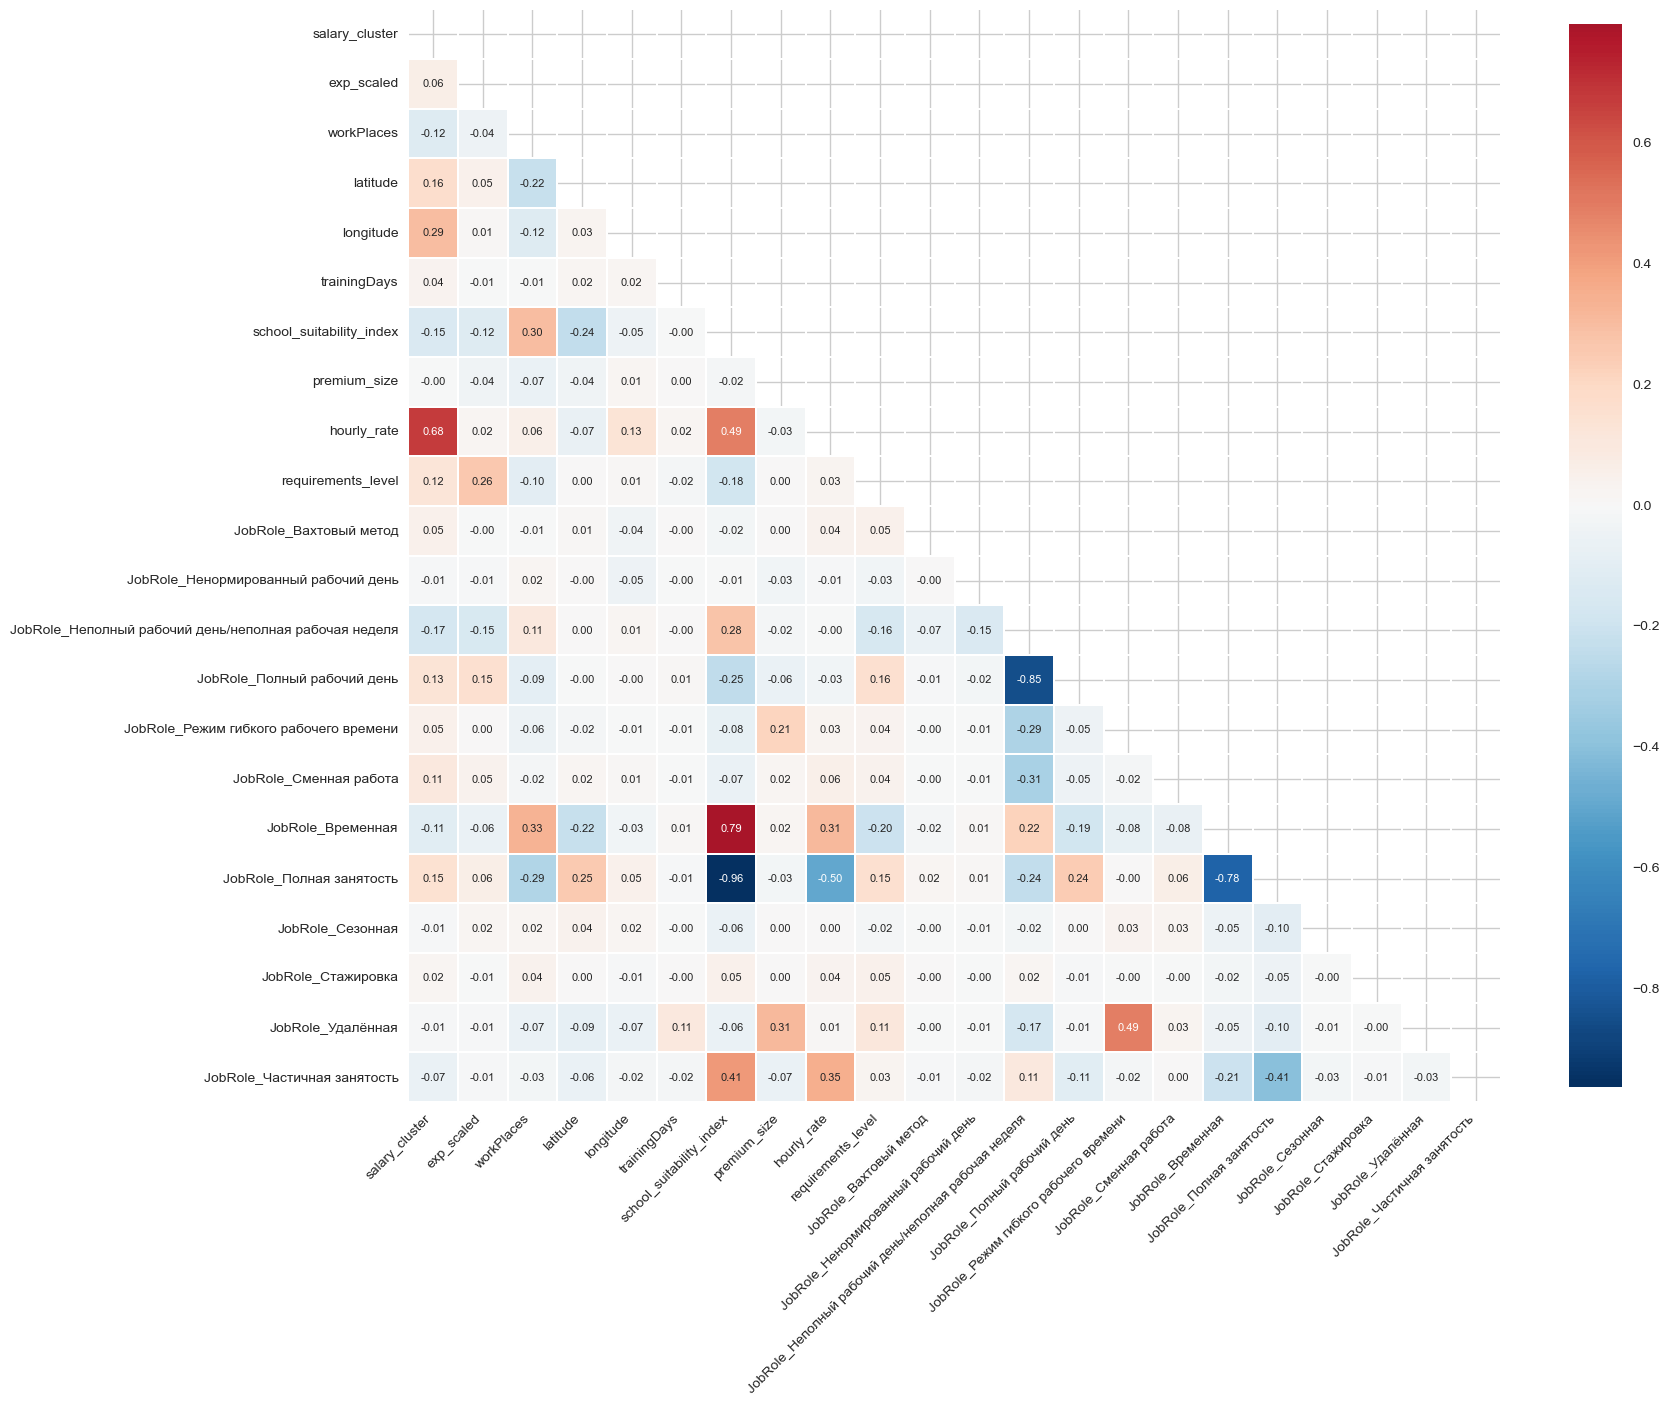

In [13]:
plt.figure(figsize=(18, 16))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdBu_r', 
            center=0,
            square=True, 
            linewidths=0.3,
            cbar_kws={"shrink": 0.8},
            annot_kws={"size": 8})


plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Мультиколлинеарность присутствует

пары со значением сильной корреляции (больше 0,7)
- school_suitability_index	и JobRole_Полная занятость:	почти мультиколлинеарная отрицательная связь
- JobRole_Неполный рабочий день и JobRole_Полный рабочий день: сильная обратная зависимость
- JobRole_Временная	и JobRole_Полная занятость: сильная обратная связь
- school_suitability_index и JobRole_Временная: сильная прямая связь

One-hot закодированные признаки закономерно коррелируют между собой, так как они взаимоисключающие 

Проблема в дублировании school_suitability_index с типами занятости

Ожидаемо hourly_rate сильно связан с зарплатой

Будем выполнять снижение размерности, исключив school_suitability_index из-за дублирования

In [14]:
pca_feat = [
    'salary_cluster',
    'exp_scaled',
    'workPlaces',
    'latitude',
    'longitude',
    'trainingDays',
    'premium_size',
    'hourly_rate',
    'requirements_level'
]

jobrole_feat = [col for col in df.columns if col.startswith('JobRole_')]

df_pca = df[pca_feat + jobrole_feat].copy()

df_pca = df_pca.fillna(df_pca.median())

In [15]:
print(f"Количество признаков: {len(pca_feat) + len(jobrole_feat)}")

Количество признаков: 21


In [16]:
# масштабирование 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_pca)

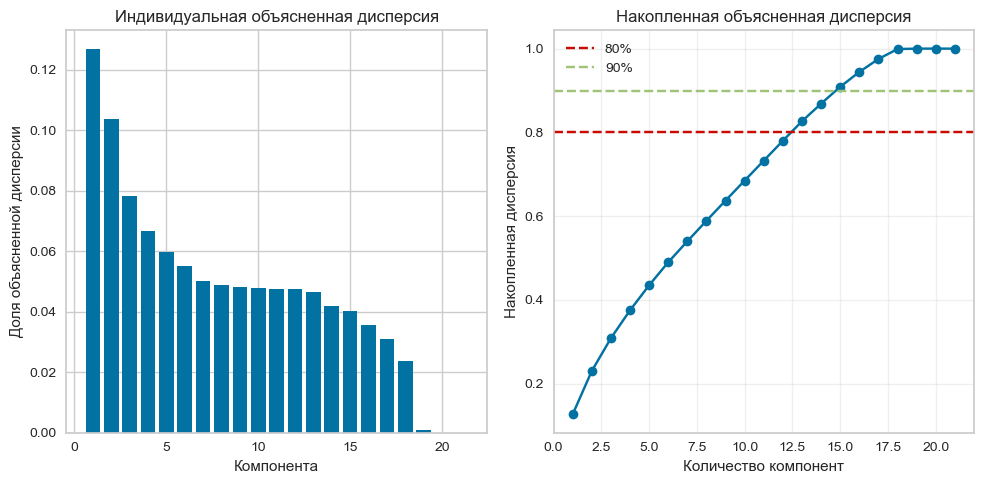

In [17]:
# PCA без ограничения числа компонент
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance_ratio = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio)
plt.xlabel('Компонента')
plt.ylabel('Доля объясненной дисперсии')
plt.title('Индивидуальная объясненная дисперсия')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, 'bo-')
plt.axhline(y=0.8, color='r', linestyle='--', label='80%')
plt.axhline(y=0.9, color='g', linestyle='--', label='90%')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная дисперсия')
plt.title('Накопленная объясненная дисперсия')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

(код для графиков писал ИИ)

По графикам первая компонента объясняет всего 12.5%, значит у нас достаточно сложная многомерная структура данных и каждая следующая компонента добавляет всего 3-5% объясненной дисперсии.  Для 80% дисперсии нужно будет 13 компонент из 22 исходных признаков. Выбираем 13 компонент.

In [18]:
# применяем PCA
n_components = 13

pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

components_df = pd.DataFrame(
    X_pca,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=df_pca.index
)

In [19]:
print(f"Размерность: {components_df.shape}")
print("\nДоля объясненной дисперсии по компонентам:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.2%}")

Размерность: (2213, 13)

Доля объясненной дисперсии по компонентам:
PC1: 12.66%
PC2: 10.36%
PC3: 7.82%
PC4: 6.67%
PC5: 5.98%
PC6: 5.49%
PC7: 5.01%
PC8: 4.90%
PC9: 4.83%
PC10: 4.77%
PC11: 4.76%
PC12: 4.75%
PC13: 4.66%


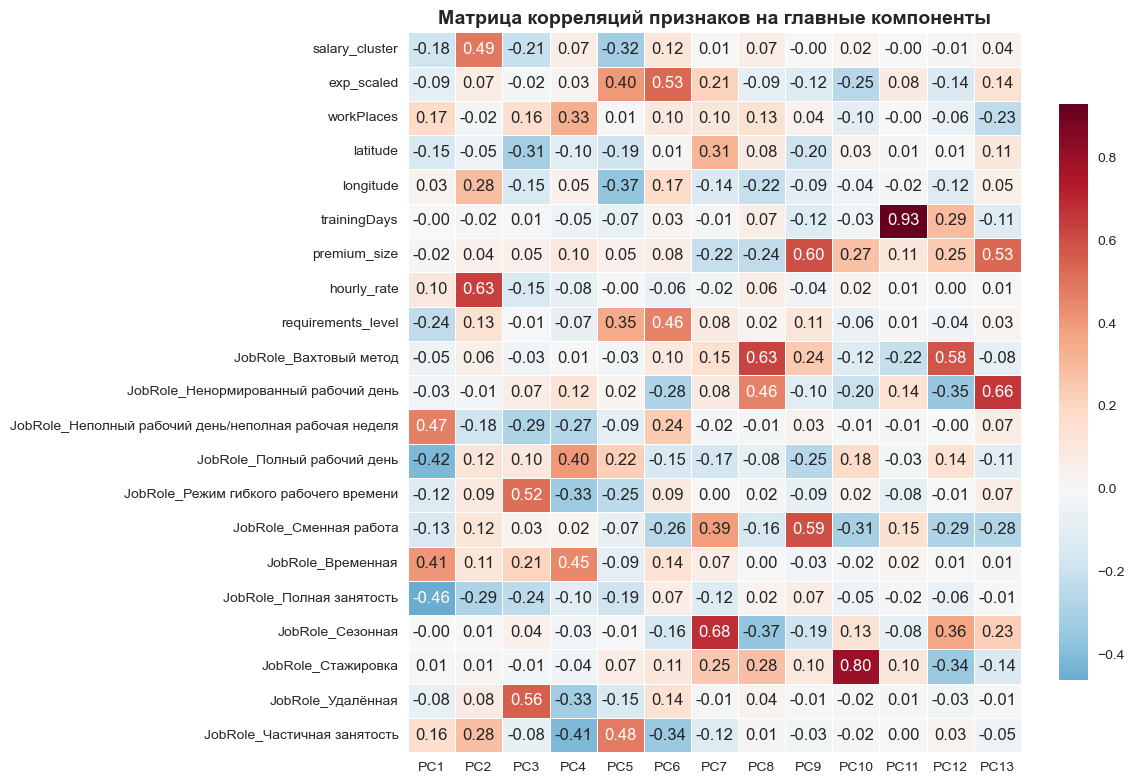

In [20]:
# тепловая карта матрицы корреляций между изначальными признаками и компонентами 
loadings = pd.DataFrame(
    pca.components_.T,
    index=df_pca.columns,
    columns=[f'PC{i+1}' for i in range(n_components)]
)

plt.figure(figsize=(12, 8))
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Матрица корреляций признаков на главные компоненты', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

salary_cluster наиболее представлена в PC2, hourly_rate также доминирует в PC2, географические признаки распределены по нескольким компонентам. Разделили исходные признаки на компоненты, первые 6 компонент объясняют 43% дисперсии и охватывают основные характеристики вакансий

In [21]:
# интерпретация главных компонент

for i in range(n_components):
    pc = f'PC{i+1}'
    explained_var = pca.explained_variance_ratio_[i]
    
    top_positive = loadings[pc].sort_values(ascending=False).head(3)
    top_negative = loadings[pc].sort_values(ascending=True).head(3)
    
    print(f"PC {i+1} - {explained_var:.1%}")
    print(f"Положительные нагрузки: {', '.join([f'{idx} ({val:.2f})' for idx, val in top_positive.items()])}")
    print(f"Отрицательные нагрузки: {', '.join([f'{idx} ({val:.2f})' for idx, val in top_negative.items()])}")

PC 1 - 12.7%
Положительные нагрузки: JobRole_Неполный рабочий день/неполная рабочая неделя (0.47), JobRole_Временная (0.41), workPlaces (0.17)
Отрицательные нагрузки: JobRole_Полная занятость (-0.46), JobRole_Полный рабочий день (-0.42), requirements_level (-0.24)
PC 2 - 10.4%
Положительные нагрузки: hourly_rate (0.63), salary_cluster (0.49), longitude (0.28)
Отрицательные нагрузки: JobRole_Полная занятость (-0.29), JobRole_Неполный рабочий день/неполная рабочая неделя (-0.18), latitude (-0.05)
PC 3 - 7.8%
Положительные нагрузки: JobRole_Удалённая (0.56), JobRole_Режим гибкого рабочего времени (0.52), JobRole_Временная (0.21)
Отрицательные нагрузки: latitude (-0.31), JobRole_Неполный рабочий день/неполная рабочая неделя (-0.29), JobRole_Полная занятость (-0.24)
PC 4 - 6.7%
Положительные нагрузки: JobRole_Временная (0.45), JobRole_Полный рабочий день (0.40), workPlaces (0.33)
Отрицательные нагрузки: JobRole_Частичная занятость (-0.41), JobRole_Режим гибкого рабочего времени (-0.33), Job

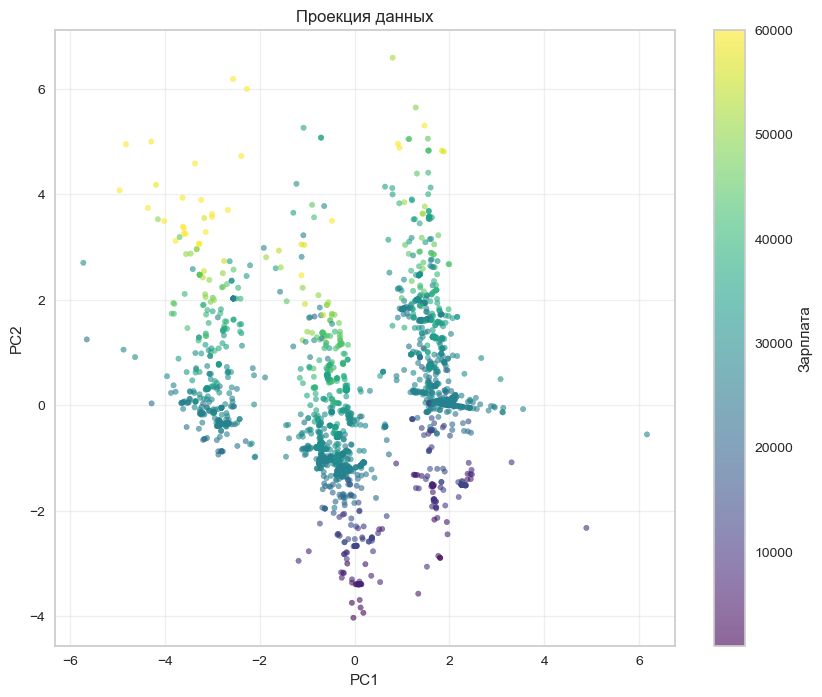

In [22]:
# Визуализация первых двух
if n_components >= 2:
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(components_df['PC1'], components_df['PC2'], 
                          c=df['salary_cluster'], cmap='viridis', 
                          alpha=0.6, s=15)
    plt.colorbar(scatter, label='Зарплата')
    plt.xlabel(f'PC1')
    plt.ylabel(f'PC2')
    plt.title('Проекция данных')
    plt.grid(True, alpha=0.3)
    plt.show()

Данные не имеют естественной кластерной структуры, так как точки распределены непрерывно. Скорее всего кластеризация будет выделять не изолированные группы, а типичные профили вакансий

In [23]:
# сохраняем компоненты
for i in range(n_components):
    df[f'PC{i+1}'] = components_df.iloc[:, i]

pca_columns = [f'PC{i+1}' for i in range(n_components)]

Я буду строить кластеризацию только на компонентах, так как исходные признаки имели сильные корреляции, а компоненты некоррелированы между собой, и объясняют бОльшую дисперсию данных. Также сниженая размерность лучше. Этот набор оптимален для кластеризации методом K-means и сможет выделить типичные профили вакансий

In [24]:
pca_feat_final = [f'PC{i+1}' for i in range(n_components)]
selected = pca_feat_final
cumulative_variance[n_components-1]

np.float64(0.8266513215000425)

In [25]:
df_clustering = df[selected].copy()
df_clustering = df_clustering.dropna()

df_clustering.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13
0,1.806656,0.035067,0.667749,0.732430,0.057722,-0.081899,0.038661,0.053278,0.010140,0.068212,0.004134,0.162587,-0.010255
1,-2.849837,-0.282652,0.453308,1.477018,0.433731,-1.244901,-0.453964,-0.078078,-0.887656,0.583995,-0.113060,0.443985,-0.465392
2,-0.305040,-1.253305,-0.626566,-0.541088,-0.460358,-0.148022,0.013027,0.095941,-0.017398,0.022478,-0.065008,0.011093,0.084217
3,-0.281815,-1.168841,-0.573434,-0.517231,-0.426072,-0.152778,-0.056101,0.098356,0.031274,0.019260,-0.067399,0.013763,0.059898
4,1.777309,0.236911,0.535753,0.743728,-0.085079,-0.038811,0.097795,0.077487,-0.047726,0.069215,0.005800,0.143342,0.007419


In [26]:
df_clustering.to_csv('clustering_final.csv', index=False)

**2. Кластерный анализ и интерпретация результатов**

Метод K-Means подходит для данных нашей размерности, хорошо будет работать с ортогональными компонентами, и у нас сглажены выбросы, поэтому проблем быть не должно.
Аггломеративная кластеризация будет медленной на наших больших данных.
DBSCAN чувствителен к параметрам и плохо работает с разной плотностью.
Смесь гауссовых распределений учитывает неопределенность, но сложнее в интерпретации и нужно больше данных.

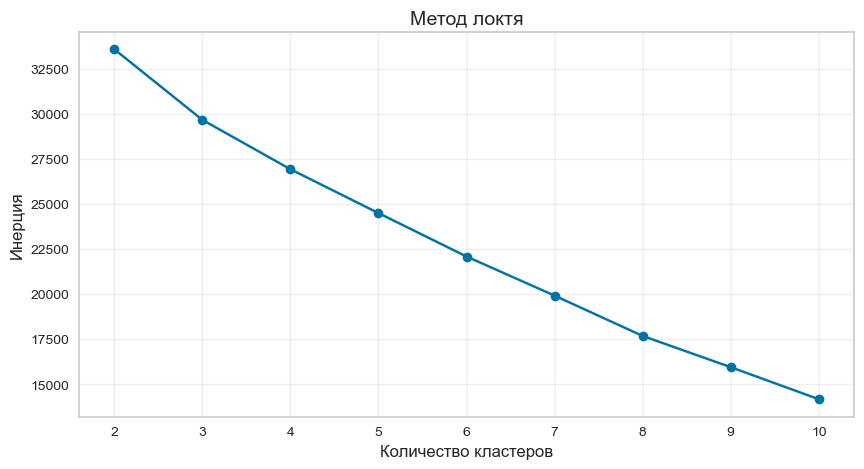

In [27]:
# метод локтя
inertia = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_clustering)
    inertia.append(kmeans.inertia_)

# График метода локтя
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Количество кластеров', fontsize=12)
plt.ylabel('Инерция', fontsize=12)
plt.title('Метод локтя', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)
plt.show()

Четкого локтя не видно

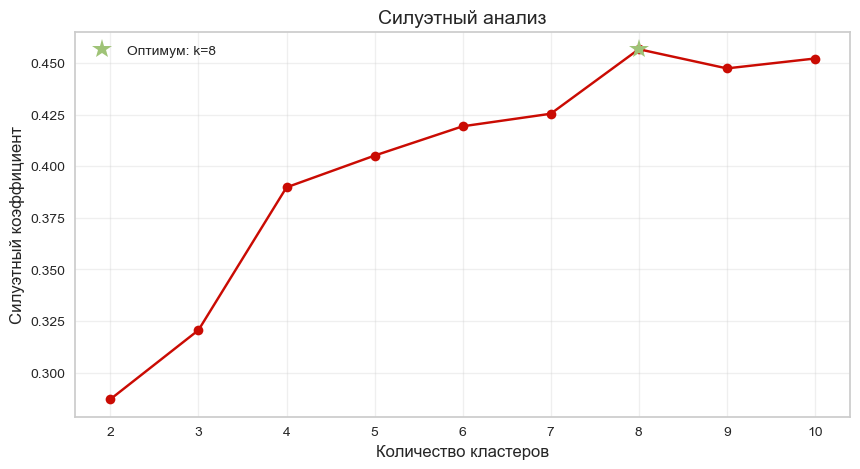

np.float64(0.4567779750553818)

In [28]:
# Силуэтный анализ
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_clustering)
    score = silhouette_score(df_clustering, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Количество кластеров', fontsize=12)
plt.ylabel('Силуэтный коэффициент', fontsize=12)
plt.title('Силуэтный анализ', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(K_range)

max_k = K_range[np.argmax(silhouette_scores)]
max_score = max(silhouette_scores)
plt.plot(max_k, max_score, 'g*', markersize=15, label=f'Оптимум: k={max_k}')
plt.legend()

plt.show()
max_score

(код для графика писал ИИ)

Максимальное значение достигается при количестве 8, после чего стабилизируется. Выбираем 8 кластеров, так как силуэтный коэффициент достигает максимума в этой точке, а более высокая детализация позволит выделить узкие сегменты рынка


In [29]:
n_clusters = 8

In [30]:
# обучаем
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(df_clustering)

In [31]:
cluster_counts = df['cluster'].value_counts().sort_index()
for i in range(n_clusters):
    count = cluster_counts[i]
    print(f"Кластер {i}: {count} объектов")

Кластер 0: 210 объектов
Кластер 1: 621 объектов
Кластер 2: 1030 объектов
Кластер 3: 39 объектов
Кластер 4: 38 объектов
Кластер 5: 263 объектов
Кластер 6: 9 объектов
Кластер 7: 3 объектов


In [32]:
cluster_sizes = {
    0: 210, 1: 621, 2: 1030, 3: 39,
    4: 38, 5: 263, 6: 9, 7: 3
}

In [33]:
key_metrics = [
    'salary_cluster',
    'hourly_rate',
    'workPlaces',
    'latitude',
    'longitude',
    'requirements_level',
]

jobrole_cols = [col for col in df.columns if col.startswith('JobRole_')]
all_metrics = key_metrics + jobrole_cols

cluster_stats = df.groupby('cluster')[all_metrics].agg(['mean', 'median', 'std'])

for cluster in sorted(df['cluster'].unique()):
    print(f"\nКластер {cluster} объектов: {cluster_sizes[cluster]}")
    cluster_data = df[df['cluster'] == cluster]
    
    print(f"Средняя зп {cluster_data['salary_cluster'].mean():.0f} руб"
          f" Медианная зп {cluster_data['salary_cluster'].median():.0f} руб")
    print(f"Часовая ставка: {cluster_data['hourly_rate'].mean():.0f} руб в час")
    print(f"Среднее кол-во рабочих мест: {cluster_data['workPlaces'].mean():.1f}")
    print(f"Широта {cluster_data['latitude'].mean():.1f}"
          f" Долгота {cluster_data['longitude'].mean():.1f}")
    print(f"Уровень требований: {cluster_data['requirements_level'].mean():.2f}")
    print(f"Метка для школьников: {cluster_data['school_suitability_index'].mean():.2f}")
    
    busy_types = []
    for col in jobrole_cols:
        if cluster_data[col].mean() > 0.1:  # более 10%
            busy_types.append(f"{col.replace('JobRole_', '')}: {cluster_data[col].mean()*100:.0f}%")
    if busy_types:
        print(f"Типы занятости: {', '.join(busy_types[:3])}")


Кластер 0 объектов: 210
Средняя зп 26299 руб Медианная зп 27093 руб
Часовая ставка: 329 руб в час
Среднее кол-во рабочих мест: 2.0
Широта 52.9 Долгота 55.9
Уровень требований: 0.82
Метка для школьников: 0.98
Типы занятости: Неполный рабочий день/неполная рабочая неделя: 99%, Частичная занятость: 100%

Кластер 1 объектов: 621
Средняя зп 27527 руб Медианная зп 27093 руб
Часовая ставка: 229 руб в час
Среднее кол-во рабочих мест: 8.9
Широта 52.7 Долгота 59.6
Уровень требований: 0.36
Метка для школьников: 0.98
Типы занятости: Неполный рабочий день/неполная рабочая неделя: 100%, Временная: 98%

Кластер 2 объектов: 1030
Средняя зп 28573 руб Медианная зп 27100 руб
Часовая ставка: 179 руб в час
Среднее кол-во рабочих мест: 2.3
Широта 54.5 Долгота 55.3
Уровень требований: 0.83
Метка для школьников: 0.00
Типы занятости: Неполный рабочий день/неполная рабочая неделя: 100%, Полная занятость: 100%

Кластер 3 объектов: 39
Средняя зп 36638 руб Медианная зп 35840 руб
Часовая ставка: 253 руб в час
Сред

In [34]:
summary = []

for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    
    summary.append({
        'Кластер': cluster,
        'Размер': cluster_sizes[cluster],
        'Доля': f"{cluster_sizes[cluster]/2213*100:.1f}%",
        'Ср. зарплата': f"{cluster_data['salary_cluster'].mean():.0f}",
        'Час. ставка': f"{cluster_data['hourly_rate'].mean():.0f}",
        'Тип занятости': cluster_data['busyType'].mode()[0] if 'busyType' in df.columns else '—',
        'Метка для школьников': f"{cluster_data['school_suitability_index'].mean():.2f}",
        'Требования': f"{cluster_data['requirements_level'].mean():.1f}"
    })

summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False))

 Кластер  Размер  Доля Ср. зарплата Час. ставка       Тип занятости Метка для школьников Требования
       0     210  9.5%        26299         329 Частичная занятость                 0.98        0.8
       1     621 28.1%        27527         229           Временная                 0.98        0.4
       2    1030 46.5%        28573         179    Полная занятость                 0.00        0.8
       3      39  1.8%        36638         253    Полная занятость                 0.13        1.2
       4      38  1.7%        31771         217    Полная занятость                 0.05        1.1
       5     263 11.9%        33375         213    Полная занятость                 0.05        1.4
       6       9  0.4%        27658         191    Полная занятость                 0.33        0.2
       7       3  0.1%        30000         250          Стажировка                 1.00        2.0


Ядром рынка является кластер 2 —  включает 46.5% вакансий с полной занятостью, не подходящих для школьников

Целевые для школьников кластеры 0 и 1 — включают 37.6% вакансий с гибкой занятостью, высокой часовой ставкой и низкими требованиями, массовый найм для кластера 1

Квалифицированные позиции кластер 5 — включает 11.9% ваканий с высокими требованиями и зарплатой, требуют навыков, не подходят для школь ников

Часовая ставка максимальна в кластере 0 - частичная занятость выгоднее при пересчете на час, подходит для школьников

Аномальные кластеры 6, 7, 3, 4 составляют всего 4%, содержат меньше всего вакансий

Кластер 7 включает стажировки, он подходит так же для школьников 


**Названия кластеров**

Кластер 0: Оптимальный. Частичная занятость, максимальная часовая ставка, низкие требования ко входу, идеальный вариант для подростков, совмещающих работу с учебой.

Кластер 1: Временные массовые позиции. Подходит для сезонных работ и массового найма.

Кластер 2: Ядро рынка. Самый массовый кластер, основа рынка, но не ориентирован на школьников.

Кластер 3: Высокооплачиваемые специалисты. Малочисленный, но престижный сегмент, не подходит для школьников

Кластер 4: Гибкий формат. Формат для квалифицированных сотрудников, не подходит для школьников.

Кластер 5: Квалифицированные работники. Профессионалы с опытом и навыками.

Кластер 6: Вахтовики. Имеет аномалию в широте, скорее всего вакансия для вахтовых рабочих.

Кластер 7: Стажировка.	Малочисленные стажировки, подходящие для школьников.

**3. Размышления над полученными результатами**

Почему сформировалась именно такая кластерная структура? Какие переменные оказались ключевыми для разделения сотрудников на группы? Плучились комбинации, которые разделили рынок на такие кластеры. Тип занятости главный фактор, разделивший кластеры с гибкими форматами и полносй занятостью. Школьный индекс отделил кластеры, доступные для подростков от остальных. Ядро рынка имеет нулевой индекс, это взрослый сегмент не подходящий для школьников. Уровень требований выделил квалифицированные кластеры с высокими значениями и низкие в массовых сегментах. Структура отражает естественное расслоение рынка по этим признакам.

Соответствуют ли результаты вашим ожиданиям или оказались неожиданными? Какие предположения о поведении сотрудников подтвердились, а какие нет? Подтвердилось, что большинство вакансий не подходит для школьников, но присутствуют гибкие форматы, которые подходят, высокие требования значит высокая зарплата, логично. Неожиданно, что частичная занятость оказалась выгоднее при пересчете на час. Временные работники набираются большими группами. В стажировках странно, что стажеры должны соответствовать высоким требованиям, но получают среднюю зарплату. В кластере 6 с ненормированным рабочим днем скорее всего присутсвует вахтовые позиции, так как есть аномалия по долготе. 

Сформулируйте практические рекомендации для HR и управления корпоративной культурой на основе выявленных кластеров. В случае школьников логично повышать часовую ставку, так как сегмент в основном работает сдельно, судя по кластеру 0. Школьников можно привлекать на массовый найм, особенно летом, когда у ребят каникулы. Судя по кластерам видно, что рынок "не готов" и не будет принимать в ближайшее время школьников на профессиональные позиции, в купе с требованиями бизнеса. Пока научились работать только со студентами, до школьников далековато. Сейчас ребят привлекают на массовые позиции в качестве подработки, за неимением других рабочих мест. Даже если подросток подходит по навыкам на массовую позицию, он не подходит по графику. Вот такой парадокс. Более качественные выводы для рынка буду делать после интервью с бизнесом.

In [38]:
df.to_csv('school_vacancies_cluster.csv', index=False, encoding='utf-8-sig')